# ProtoHedge Asian-Call Real-Data Panel

This notebook runs the full 10-ticker real-data ProtoHedge panel using an **Asian short-call liability** on the same historical episode set used in the European-call study. The hedge instruments remain spot and the observed vanilla ATM call from the panel data.

The notebook is structured to:
1. run the full per-ticker ProtoHedge sweep,
2. aggregate cross-ticker results,
3. generate paper-ready tables and figures,
4. verify prototype interpretability on a representative ticker.


In [1]:

from pathlib import Path
import sys
import os
import shutil
import json

cwd = Path.cwd().resolve()
if (cwd / 'world_real_torch.py').exists():
    REPO_ROOT = cwd
elif (cwd.parent / 'world_real_torch.py').exists():
    REPO_ROOT = cwd.parent
else:
    raise RuntimeError(f'Could not locate repo root from {cwd}')

os.environ.setdefault('MPLCONFIGDIR', str((REPO_ROOT / '.matplotlib-cache').resolve()))
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from IPython.display import display, Markdown

REPO_PARENT = REPO_ROOT.parent
repo_parent_str = str(REPO_PARENT)
sys.path = [p for p in sys.path if Path(p or '.').resolve() != REPO_PARENT]
sys.path.insert(0, repo_parent_str)
for mod_name in list(sys.modules):
    if mod_name == 'deephedging' or mod_name.startswith('deephedging.'):
        del sys.modules[mod_name]

from deephedging.real_data_sweep_torch import run_real_data_sweep, MODEL_FEATURES
from deephedging.real_data_analysis_torch import (
    evaluate_saved_artifact,
    evaluate_saved_baselines,
    list_saved_artifacts,
    build_regime_frame,
    summarize_by_regime,
    prototype_usage_table,
    prototype_usage_by_regime,
)
from deephedging.prototype_extraction_torch import extract_agent_feature_matrix
from deephedging.proto_analysis_torch import load_prototype_payload

pd.set_option('display.max_columns', 300)
pd.set_option('display.width', 220)
plt.rcParams['figure.dpi'] = 120

FINAL_RUN_ROOT = REPO_ROOT / '.deephedging_real_runs' / 'final_paper_asian_panel'
FINAL_RUN_ROOT.mkdir(parents=True, exist_ok=True)
PAPER_ASSET_DIR = REPO_ROOT / 'paper' / 'final_notebook_assets'
PAPER_ASSET_DIR.mkdir(parents=True, exist_ok=True)
ASIAN_PANEL_SUBDIR = 'asian_real_data_panel'
ASIAN_PANEL_ASSET_DIR = PAPER_ASSET_DIR / ASIAN_PANEL_SUBDIR
ASIAN_PANEL_ASSET_DIR.mkdir(parents=True, exist_ok=True)


def _unique_path(path: Path) -> Path:
    path = Path(path)
    if not path.exists():
        return path
    stem = path.stem
    suffix = path.suffix
    i = 2
    while True:
        cand = path.with_name(f"{stem}_{i}{suffix}")
        if not cand.exists():
            return cand
        i += 1


def save_current_figure(name, subdir=ASIAN_PANEL_SUBDIR, dpi=180):
    subdir_path = PAPER_ASSET_DIR / subdir
    subdir_path.mkdir(parents=True, exist_ok=True)
    path = _unique_path(subdir_path / f'{name}.png')
    plt.gcf().savefig(path, dpi=dpi, bbox_inches='tight')
    print('saved figure:', path)
    return path


def save_dataframe(df, name, subdir=f'{ASIAN_PANEL_SUBDIR}/tables', latex=True, index=False):
    subdir_path = PAPER_ASSET_DIR / subdir
    subdir_path.mkdir(parents=True, exist_ok=True)
    csv_path = subdir_path / f'{name}.csv'
    df.to_csv(csv_path, index=index)
    print('saved table:', csv_path)
    if latex:
        tex_path = subdir_path / f'{name}.tex'
        try:
            tex = df.to_latex(index=index, escape=False, float_format=lambda x: f"{x:.6f}" if isinstance(x, (float, np.floating)) else str(x))
            tex_path.write_text(tex)
            print('saved latex:', tex_path)
        except Exception as exc:
            print('latex export skipped:', exc)
    return csv_path


def maybe_copy(src, subdir=f'{ASIAN_PANEL_SUBDIR}/copied_assets'):
    src = Path(src)
    if not src.exists():
        print('missing asset:', src)
        return None
    dst_dir = PAPER_ASSET_DIR / subdir
    dst_dir.mkdir(parents=True, exist_ok=True)
    dst = _unique_path(dst_dir / src.name)
    shutil.copy2(src, dst)
    print('copied asset:', dst)
    return dst


def expanded_feature_cols(feature_names, world, input_dim):
    per_step = world.data.features.per_step
    n_inst = int(world.nInst)
    cols = []
    count = 0
    for name in sorted(feature_names or ['price', 'delta', 'time_left']):
        if name in per_step:
            arr = np.asarray(per_step[name])
            width = 1 if arr.ndim == 2 else int(arr.shape[-1])
        elif name in ['delta', 'action']:
            width = n_inst
        elif name in ['pnl', 'cost']:
            width = 1
        else:
            width = 1
        if width == 1:
            cols.append(name)
            count += 1
        else:
            for j in range(width):
                cols.append(f'{name}_{j}')
                count += 1
    if count != int(input_dim):
        cols = [f'feature_{i}' for i in range(int(input_dim))]
    return cols


def select_best_row(best_df, preferred_selection, fallback_selections=()):
    for selection in (preferred_selection, *fallback_selections):
        sub = best_df[best_df['selection'] == selection]
        if not sub.empty:
            return sub.iloc[0]
    raise ValueError(f'Could not find preferred selection {preferred_selection} in best_df')

print('repo root:', REPO_ROOT)
print('final run root:', FINAL_RUN_ROOT)
print('paper assets:', PAPER_ASSET_DIR)


repo root: /Users/yaniszaim/deephedging
final run root: /Users/yaniszaim/deephedging/.deephedging_real_runs/final_paper_asian_panel
paper assets: /Users/yaniszaim/deephedging/paper/final_notebook_assets


## Controls

The defaults below are set for the **full Asian-call panel run**.


In [2]:

RUN_PANEL_SWEEP = True


## Panel Setup

This section loads the processed 10-ticker panel and configures the Asian-call sweep.


In [3]:

PANEL_DIR = REPO_ROOT / 'Data' / 'NEW_PANEL'
MANIFEST_PATH = PANEL_DIR / 'panel_manifest.csv'
assert MANIFEST_PATH.exists(), f'Missing panel manifest: {MANIFEST_PATH}'
manifest = pd.read_csv(MANIFEST_PATH)
manifest = manifest.sort_values('ticker').reset_index(drop=True)
display(manifest)

PANEL_OUTPUT_ROOT = FINAL_RUN_ROOT / 'panel_sweeps'
PANEL_OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
PANEL_SUMMARY_DIR = PANEL_OUTPUT_ROOT / 'panel_summary'
PANEL_SUMMARY_DIR.mkdir(parents=True, exist_ok=True)

PANEL_TICKERS = None   # None = every processed ticker in the manifest
SEEDS = (1234, 2345, 3456)
EPOCHS = 800
TRAIN_FRAC = 0.70
VAL_FRAC = 0.15
NORMALIZE_REAL_WORLD = True
HEDGE_MODE = 'step'
USE_POSITION_BOUNDS = True
SKIP_COMPLETED_TICKERS = True
FORCE_RERUN_TICKERS = set()
PANEL_COMPLETION_FILES = (
    'sweep_metrics.csv',
    'sweep_test_summary.csv',
    'paper_model_comparison.csv',
    'paper_best_models.csv',
)

LIABILITY_TYPE = 'asian_call'
ASIAN_AVERAGE_TYPE = 'arithmetic'
ASIAN_START_STEP = 0
ASIAN_END_STEP = None

TRADE_BOUNDS = {
    'lbnd_as': -1.0,
    'ubnd_as': 1.0,
    'lbnd_av': -1.0,
    'ubnd_av': 1.0,
}
POSITION_BOUNDS = {
    'lbnd_delta_s': -1.0,
    'ubnd_delta_s': 1.0,
    'lbnd_delta_v': -1.0,
    'ubnd_delta_v': 1.0,
}
TRAIN_SELECTION_CFG = {
    'selection_metric': 'val_loss',
    'selection_alpha_action_abs': 0.005,
    'selection_alpha_delta_abs': 0.010,
    'selection_alpha_bound_occupancy': 0.100,
    'selection_alpha_path_bound_touch': 0.0,
}
TRAIN_REG_CFG = {
    'action_penalty_weight': 0.001,
    'delta_penalty_weight': 0.002,
}
ROBUST_SCREEN_CFG = {
    'max_bound_occupancy': 0.50,
    'max_path_touch_rate': None,
}

PANEL_SWEEP_MODE = 'full_paper_grid'  # alternatives: 'frontier_only'
if PANEL_SWEEP_MODE == 'full_paper_grid':
    PROTOTYPE_COUNTS = (10, 25, 50, 100)
    PROTOTYPE_SOURCES = ('spot_delta', 'vanilla')
    WEIGHTED_SIMILARITY_OPTIONS = (False, True)
    LEARN_DISTANCE_FEATURE_WEIGHTS_OPTIONS = (False,)
else:
    PROTOTYPE_COUNTS = (10, 25)
    PROTOTYPE_SOURCES = ('spot_delta',)
    WEIGHTED_SIMILARITY_OPTIONS = (False,)
    LEARN_DISTANCE_FEATURE_WEIGHTS_OPTIONS = (False,)

PANEL_BASELINE_LABELS = {
    'unhedged': 'Unhedged',
    'spot_delta': 'Spot-Delta',
    'spot_delta_band': 'Spot-Delta Band',
    'vanilla': 'Vanilla DH',
}
PANEL_PROTO_SELECTION_LABELS = {
    'best_screened_proto_mean': 'ProtoHedge (Mean frontier)',
    'best_screened_proto_cvar05': 'ProtoHedge (Tail frontier)',
    'best_screened_proto_shortfall': 'ProtoHedge (Shortfall frontier)',
}
PANEL_PAPER_LABEL_ORDER = [
    'Unhedged',
    'Spot-Delta',
    'Spot-Delta Band',
    'Vanilla DH',
    'ProtoHedge (Mean frontier)',
    'ProtoHedge (Tail frontier)',
    'ProtoHedge (Shortfall frontier)',
]
DEEP_DIVE_TICKER = 'QQQ'
DEEP_DIVE_SEED = int(SEEDS[0])
DEEP_DIVE_SELECTION = 'best_screened_proto_cvar05'

if PANEL_TICKERS is not None:
    manifest = manifest[manifest['ticker'].isin(PANEL_TICKERS)].copy().reset_index(drop=True)

if DEEP_DIVE_TICKER not in manifest['ticker'].tolist():
    DEEP_DIVE_TICKER = str(manifest['ticker'].iloc[0])

print('panel tickers:', manifest['ticker'].tolist())
print('panel sweep mode:', PANEL_SWEEP_MODE)
print('liability type:', LIABILITY_TYPE)
print('asian average type:', ASIAN_AVERAGE_TYPE)
print('skip completed tickers:', SKIP_COMPLETED_TICKERS)
print('panel output root:', PANEL_OUTPUT_ROOT)


,ticker,status,spot_path,options_path,clean_spot_path,feature_path,episode_path,n_spot_rows,n_option_rows,n_feature_rows,n_episodes,feature_start_date,feature_end_date,strike_scale,n_steps,min_dte,max_dte,max_gap_days,n_gap_breaks,max_observed_gap_days
0,AAPL,ok,/Users/yaniszaim/deephedging/Data/NEW DATA/AAP...,/Users/yaniszaim/deephedging/Data/NEW DATA/AAP...,/Users/yaniszaim/deephedging/Data/NEW_PANEL/cl...,/Users/yaniszaim/deephedging/Data/NEW_PANEL/fe...,/Users/yaniszaim/deephedging/Data/NEW_PANEL/ep...,5033,460033,4332,3033,2005-01-11,2024-12-31,1000.0,20,20,40,4,94,19
1,IWM,ok,/Users/yaniszaim/deephedging/Data/NEW DATA/IWM...,/Users/yaniszaim/deephedging/Data/NEW DATA/IWM...,/Users/yaniszaim/deephedging/Data/NEW_PANEL/cl...,/Users/yaniszaim/deephedging/Data/NEW_PANEL/fe...,/Users/yaniszaim/deephedging/Data/NEW_PANEL/ep...,5033,755481,4505,3385,2005-01-11,2024-12-31,1000.0,20,20,40,4,69,19
2,NVDA,ok,/Users/yaniszaim/deephedging/Data/NEW DATA/NVD...,/Users/yaniszaim/deephedging/Data/NEW DATA/NVD...,/Users/yaniszaim/deephedging/Data/NEW_PANEL/cl...,/Users/yaniszaim/deephedging/Data/NEW_PANEL/fe...,/Users/yaniszaim/deephedging/Data/NEW_PANEL/ep...,5033,521604,4272,2854,2005-01-11,2024-12-31,1000.0,20,20,40,4,103,19
3,QQQ,ok,/Users/yaniszaim/deephedging/Data/NEW DATA/QQQ...,/Users/yaniszaim/deephedging/Data/NEW DATA/QQQ...,/Users/yaniszaim/deephedging/Data/NEW_PANEL/cl...,/Users/yaniszaim/deephedging/Data/NEW_PANEL/fe...,/Users/yaniszaim/deephedging/Data/NEW_PANEL/ep...,5033,921394,4505,3385,2005-01-11,2024-12-31,1000.0,20,20,40,4,69,19
4,SPY,ok,/Users/yaniszaim/deephedging/Data/NEW DATA/SPY...,/Users/yaniszaim/deephedging/Data/NEW DATA/SPY...,/Users/yaniszaim/deephedging/Data/NEW_PANEL/cl...,/Users/yaniszaim/deephedging/Data/NEW_PANEL/fe...,/Users/yaniszaim/deephedging/Data/NEW_PANEL/ep...,5033,1426013,4505,3385,2005-01-11,2024-12-31,1000.0,20,20,40,4,69,19
5,TLT,ok,/Users/yaniszaim/deephedging/Data/NEW DATA/TLT...,/Users/yaniszaim/deephedging/Data/NEW DATA/TLT...,/Users/yaniszaim/deephedging/Data/NEW_PANEL/cl...,/Users/yaniszaim/deephedging/Data/NEW_PANEL/fe...,/Users/yaniszaim/deephedging/Data/NEW_PANEL/ep...,5033,447663,4265,2846,2005-01-11,2024-12-31,1000.0,20,20,40,4,103,19
6,XLE,ok,/Users/yaniszaim/deephedging/Data/NEW DATA/XLE...,/Users/yaniszaim/deephedging/Data/NEW DATA/XLE...,/Users/yaniszaim/deephedging/Data/NEW_PANEL/cl...,/Users/yaniszaim/deephedging/Data/NEW_PANEL/fe...,/Users/yaniszaim/deephedging/Data/NEW_PANEL/ep...,5033,419741,4455,3201,2005-01-11,2024-12-31,1000.0,20,20,40,4,77,19
7,XLF,ok,/Users/yaniszaim/deephedging/Data/NEW DATA/XLF...,/Users/yaniszaim/deephedging/Data/NEW DATA/XLF...,/Users/yaniszaim/deephedging/Data/NEW_PANEL/cl...,/Users/yaniszaim/deephedging/Data/NEW_PANEL/fe...,/Users/yaniszaim/deephedging/Data/NEW_PANEL/ep...,5033,274542,4331,3032,2005-01-11,2024-12-31,1000.0,20,20,40,4,94,19
8,XLK,ok,/Users/yaniszaim/deephedging/Data/NEW DATA/XLK...,/Users/yaniszaim/deephedging/Data/NEW DATA/XLK...,/Users/yaniszaim/deephedging/Data/NEW_PANEL/cl...,/Users/yaniszaim/deephedging/Data/NEW_PANEL/fe...,/Users/yaniszaim/deephedging/Data/NEW_PANEL/ep...,5033,369024,4265,2846,2005-01-11,2024-12-31,1000.0,20,20,40,4,103,19
9,XLV,ok,/Users/yaniszaim/deephedging/Data/NEW DATA/XLV...,/Users/yaniszaim/deephedging/Data/NEW DATA/XLV...,/Users/yaniszaim/deephedging/Data/NEW_PANEL/cl...,/Users/yaniszaim/deephedging/Data/NEW_PANEL/fe...,/Users/yaniszaim/deephedging/Data/NEW_PANEL/ep...,5033,359144,4263,2830,2005-01-11,2024-12-31,1000.0,20,20,40,4,104,19


panel tickers: ['AAPL', 'IWM', 'NVDA', 'QQQ', 'SPY', 'TLT', 'XLE', 'XLF', 'XLK', 'XLV']
panel sweep mode: full_paper_grid
liability type: asian_call
asian average type: arithmetic
skip completed tickers: True
panel output root: /Users/yaniszaim/deephedging/.deephedging_real_runs/final_paper_asian_panel/panel_sweeps


saved figure: /Users/yaniszaim/deephedging/paper/final_notebook_assets/asian_real_data_panel/asian_panel_manifest_diagnostics_6.png


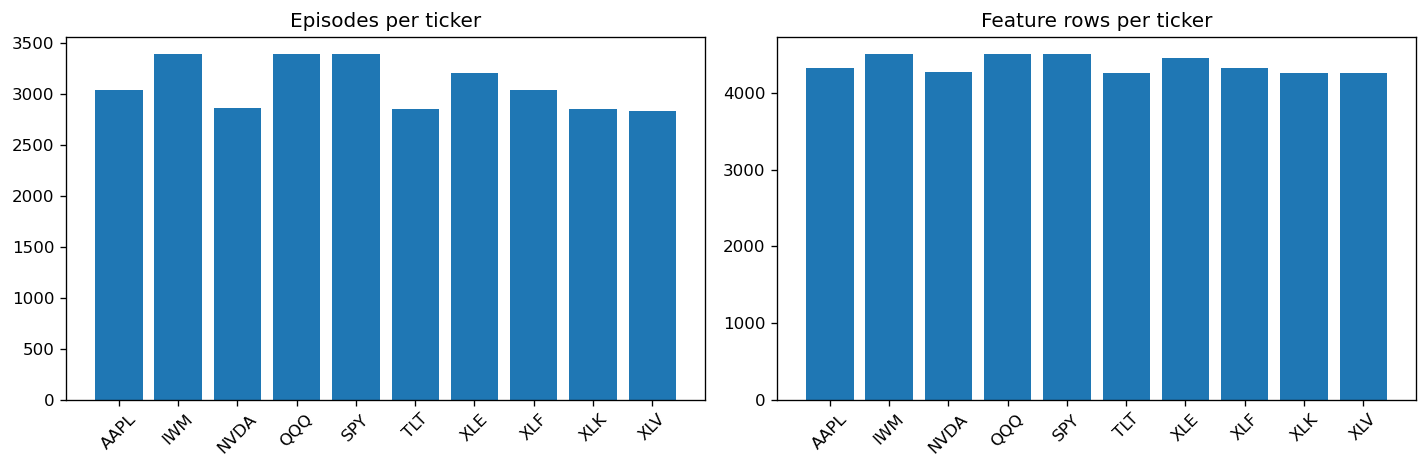

In [4]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
show = manifest[['ticker', 'n_episodes', 'n_feature_rows']].copy()
axes[0].bar(show['ticker'], show['n_episodes'])
axes[0].set_title('Episodes per ticker')
axes[0].tick_params(axis='x', rotation=45)
axes[1].bar(show['ticker'], show['n_feature_rows'])
axes[1].set_title('Feature rows per ticker')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
save_current_figure('asian_panel_manifest_diagnostics', subdir=ASIAN_PANEL_SUBDIR)
plt.show()


## Run Full Asian Panel Sweep

This is the expensive cell. It runs the full per-ticker ProtoHedge grid with the Asian-call liability. Completed ticker sweeps are skipped automatically on reruns.


In [5]:

def ticker_output_dir(ticker):
    return PANEL_OUTPUT_ROOT / f'{ticker}_{PANEL_SWEEP_MODE}_{EPOCHS}_{LIABILITY_TYPE}_step_robust'


def ticker_is_complete(ticker):
    out_dir = ticker_output_dir(ticker)
    return all((out_dir / name).exists() for name in PANEL_COMPLETION_FILES)


def load_existing_ticker_metrics(ticker):
    out_dir = ticker_output_dir(ticker)
    metrics_path = out_dir / 'sweep_metrics.csv'
    if metrics_path.exists():
        return pd.read_csv(metrics_path)
    return pd.DataFrame()


def run_one_ticker(row):
    ticker = row['ticker']
    out_dir = ticker_output_dir(ticker)
    out_dir.mkdir(parents=True, exist_ok=True)
    if (
        SKIP_COMPLETED_TICKERS
        and ticker not in FORCE_RERUN_TICKERS
        and ticker_is_complete(ticker)
    ):
        print(f'===== {ticker}: found completed sweep, skipping retrain =====')
        return load_existing_ticker_metrics(ticker)

    print(f'===== {ticker}: running {PANEL_SWEEP_MODE} sweep for {LIABILITY_TYPE} =====')
    metrics_df = run_real_data_sweep(
        data_path=row['episode_path'],
        output_dir=out_dir,
        samples=None,
        train_frac=TRAIN_FRAC,
        val_frac=VAL_FRAC,
        seeds=SEEDS,
        epochs=EPOCHS,
        prototype_counts=PROTOTYPE_COUNTS,
        prototype_sources=PROTOTYPE_SOURCES,
        weighted_similarity_options=WEIGHTED_SIMILARITY_OPTIONS,
        learn_distance_feature_weights_options=LEARN_DISTANCE_FEATURE_WEIGHTS_OPTIONS,
        risk_measures=('cvar',),
        normalize=NORMALIZE_REAL_WORLD,
        hedge_mode=HEDGE_MODE,
        position_bounds=USE_POSITION_BOUNDS,
        trade_bounds=TRADE_BOUNDS,
        cumulative_bounds=POSITION_BOUNDS,
        liability_type=LIABILITY_TYPE,
        asian_average_type=ASIAN_AVERAGE_TYPE,
        asian_start_step=ASIAN_START_STEP,
        asian_end_step=ASIAN_END_STEP,
        selection_metric=TRAIN_SELECTION_CFG['selection_metric'],
        selection_alpha_action_abs=TRAIN_SELECTION_CFG['selection_alpha_action_abs'],
        selection_alpha_delta_abs=TRAIN_SELECTION_CFG['selection_alpha_delta_abs'],
        selection_alpha_bound_occupancy=TRAIN_SELECTION_CFG['selection_alpha_bound_occupancy'],
        selection_alpha_path_bound_touch=TRAIN_SELECTION_CFG['selection_alpha_path_bound_touch'],
        action_penalty_weight=TRAIN_REG_CFG['action_penalty_weight'],
        delta_penalty_weight=TRAIN_REG_CFG['delta_penalty_weight'],
        max_bound_occupancy=ROBUST_SCREEN_CFG['max_bound_occupancy'],
        max_path_touch_rate=ROBUST_SCREEN_CFG['max_path_touch_rate'],
        tuned_baseline_metric='gains_mean',
    )
    return metrics_df

if RUN_PANEL_SWEEP:
    panel_metrics = {}
    for _, row in manifest.iterrows():
        panel_metrics[row['ticker']] = run_one_ticker(row)
else:
    print('RUN_PANEL_SWEEP=False, skipping sweep execution.')


===== AAPL: found completed sweep, skipping retrain =====
===== IWM: found completed sweep, skipping retrain =====
===== NVDA: found completed sweep, skipping retrain =====
===== QQQ: found completed sweep, skipping retrain =====
===== SPY: running full_paper_grid sweep for asian_call =====

=== seed=1234 tuned spot-delta band ===
selected band=0.0200 by gains_mean

[checkpoint:seed_1234_baselines] saved 9 metric rows to /Users/yaniszaim/deephedging/.deephedging_real_runs/final_paper_asian_panel/panel_sweeps/SPY_full_paper_grid_800_asian_call_step_robust/sweep_metrics.csv

=== seed=1234 risk=cvar vanilla ===

PyTorch version 2.11.0 running on 8 CPUs and 0 GPUs
epoch 0 | batch 0.0439 | train 0.0417 | val 0.0435 | select 0.1250

[checkpoint:seed_1234_risk_cvar_vanilla] saved 12 metric rows to /Users/yaniszaim/deephedging/.deephedging_real_runs/final_paper_asian_panel/panel_sweeps/SPY_full_paper_grid_800_asian_call_step_robust/sweep_metrics.csv

=== proto_source=spot_delta_k=10_weighted=0

## Aggregate Cross-Ticker Outputs

These cells collect the per-ticker sweep outputs and build the panel summary tables and figures.


In [6]:

def load_panel_outputs_for_ticker(ticker):
    out_dir = ticker_output_dir(ticker)
    comp_path = out_dir / 'paper_model_comparison.csv'
    best_path = out_dir / 'paper_best_models.csv'
    assert comp_path.exists(), f'Missing paper_model_comparison.csv for {ticker}: {comp_path}'
    assert best_path.exists(), f'Missing paper_best_models.csv for {ticker}: {best_path}'
    comp = pd.read_csv(comp_path)
    best = pd.read_csv(best_path)
    artifact_index = list_saved_artifacts(out_dir)
    return out_dir, comp, best, artifact_index

panel_rows = []
panel_all_rows = []
panel_best_rows = []
for _, mrow in manifest.iterrows():
    ticker = mrow['ticker']
    out_dir, comp, best, artifact_index = load_panel_outputs_for_ticker(ticker)
    comp = comp.copy()
    comp['ticker'] = ticker
    comp['output_dir'] = str(out_dir)
    panel_all_rows.append(comp)

    for model, label in PANEL_BASELINE_LABELS.items():
        sub = comp[comp['model'] == model]
        if sub.empty:
            continue
        row = sub.iloc[0].to_dict()
        row['paper_label'] = label
        row['selection'] = model
        panel_rows.append(row)

    for selection, label in PANEL_PROTO_SELECTION_LABELS.items():
        try:
            best_row = select_best_row(
                best,
                selection,
                fallback_selections=(selection.replace('best_screened_', 'best_'),),
            )
        except Exception:
            continue
        row = best_row.to_dict()
        row['ticker'] = ticker
        row['paper_label'] = label
        row['output_dir'] = str(out_dir)
        panel_rows.append(row)
        panel_best_rows.append(row)

panel_df = pd.DataFrame(panel_rows)
panel_all_models_df = pd.concat(panel_all_rows, axis=0, ignore_index=True)
panel_best_df = pd.DataFrame(panel_best_rows)

panel_df['paper_label'] = pd.Categorical(panel_df['paper_label'], PANEL_PAPER_LABEL_ORDER, ordered=True)
panel_df = panel_df.sort_values(['ticker', 'paper_label']).reset_index(drop=True)
panel_df.to_csv(PANEL_SUMMARY_DIR / 'panel_model_metrics.csv', index=False)
panel_all_models_df.to_csv(PANEL_SUMMARY_DIR / 'panel_all_models.csv', index=False)
panel_best_df.to_csv(PANEL_SUMMARY_DIR / 'panel_best_rows.csv', index=False)
print('saved:', PANEL_SUMMARY_DIR / 'panel_model_metrics.csv')
print('saved:', PANEL_SUMMARY_DIR / 'panel_all_models.csv')
display(panel_df[['ticker', 'paper_label', 'gains_mean_avg', 'gains_mean_std', 'gains_cvar05_avg', 'shortfall_prob_avg', 'pct_at_any_position_bound_avg', 'passes_robust_screen']])


saved: /Users/yaniszaim/deephedging/.deephedging_real_runs/final_paper_asian_panel/panel_sweeps/panel_summary/panel_model_metrics.csv
saved: /Users/yaniszaim/deephedging/.deephedging_real_runs/final_paper_asian_panel/panel_sweeps/panel_summary/panel_all_models.csv


,ticker,paper_label,gains_mean_avg,gains_mean_std,gains_cvar05_avg,shortfall_prob_avg,pct_at_any_position_bound_avg,passes_robust_screen
0,AAPL,Unhedged,-0.020650,NaN,-0.080852,0.559211,0.000000,True
1,AAPL,Spot-Delta,-0.019956,NaN,-0.075825,0.804825,0.000000,True
2,AAPL,Spot-Delta Band,-0.020070,NaN,-0.075484,0.815789,0.000000,True
3,IWM,Unhedged,-0.015521,0.000101,-0.077279,0.595940,0.000000,True
4,IWM,Spot-Delta,-0.015513,0.000189,-0.075485,0.806156,0.000000,True
...,...,...,...,...,...,...,...,...
61,XLV,Spot-Delta Band,-0.010386,0.001050,-0.051206,0.798122,0.000000,True
62,XLV,Vanilla DH,-0.010329,0.000824,-0.052205,0.944444,0.000000,True
63,XLV,ProtoHedge (Mean frontier),-0.010140,0.000836,-0.049266,0.845070,0.001174,True
64,XLV,ProtoHedge (Tail frontier),-0.010140,0.000836,-0.049266,0.845070,0.001174,True


saved figure: /Users/yaniszaim/deephedging/paper/final_notebook_assets/asian_real_data_panel/asian_panel_mean_heatmap_3.png


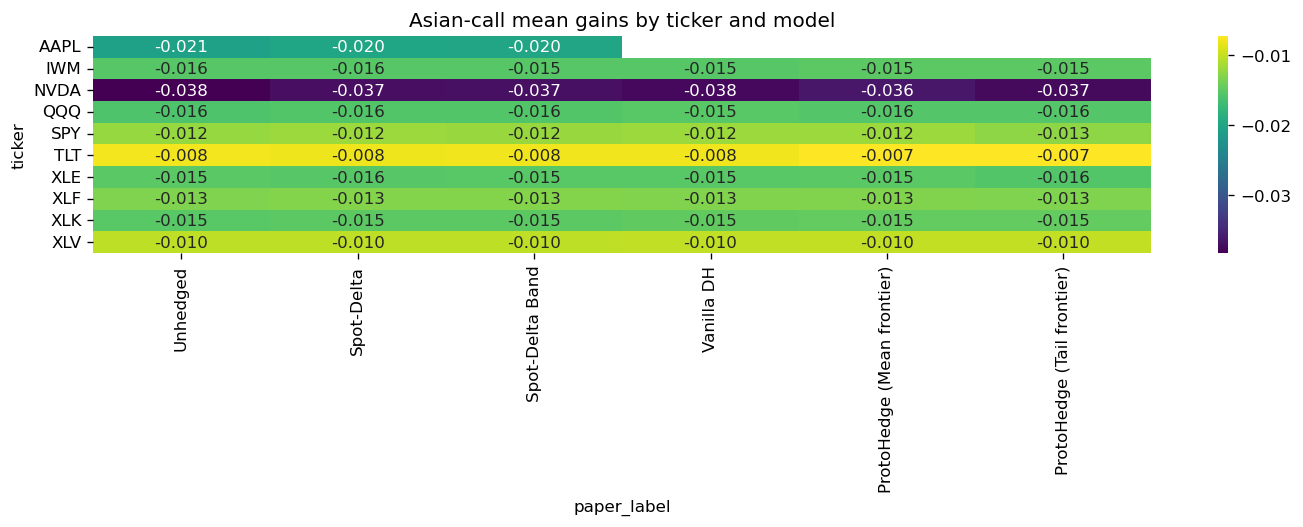

saved figure: /Users/yaniszaim/deephedging/paper/final_notebook_assets/asian_real_data_panel/asian_panel_cvar_heatmap_3.png


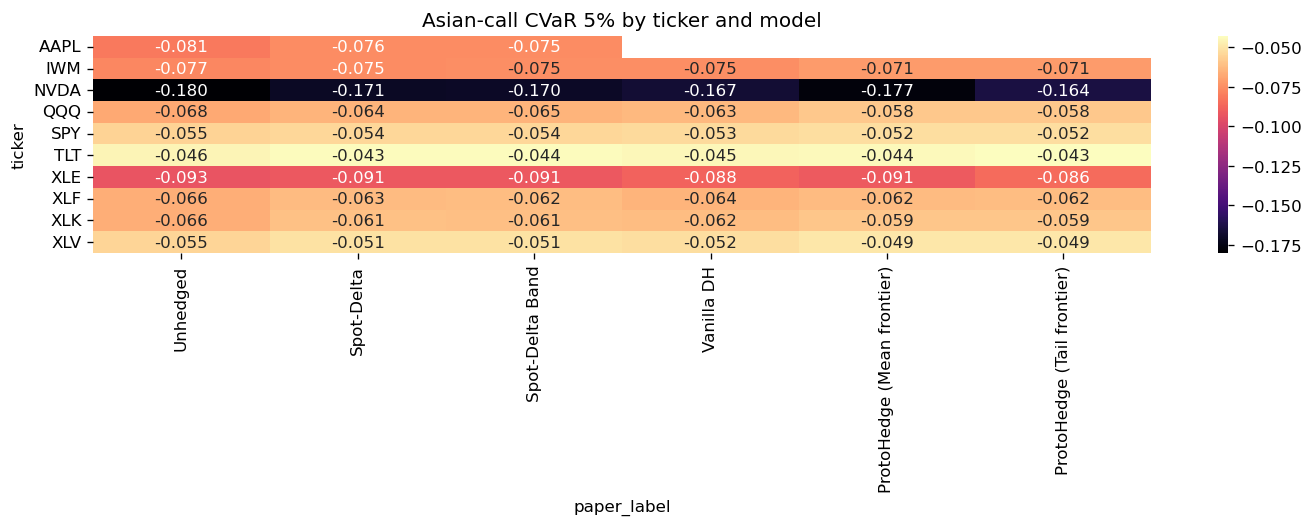

saved figure: /Users/yaniszaim/deephedging/paper/final_notebook_assets/asian_real_data_panel/asian_panel_bound_heatmap_3.png


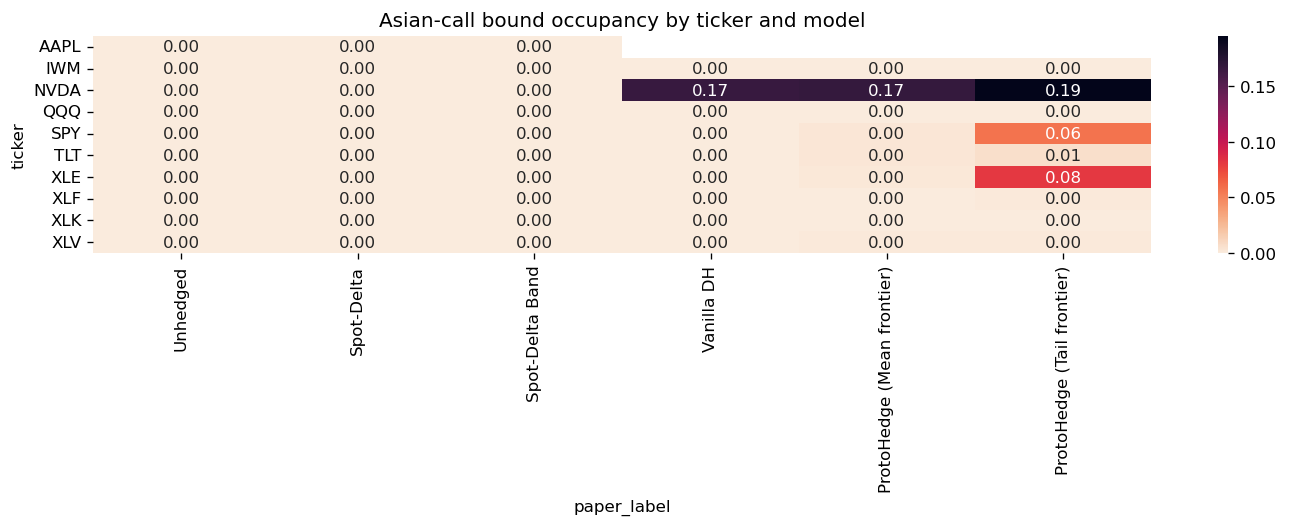

/var/folders/jb/zpyhvlmx055309q_kylk0h000000gp/T/ipykernel_14612/3321754700.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for label, grp in proto_gap.groupby('paper_label'):


saved figure: /Users/yaniszaim/deephedging/paper/final_notebook_assets/asian_real_data_panel/asian_panel_proto_vs_vanilla_gaps_3.png


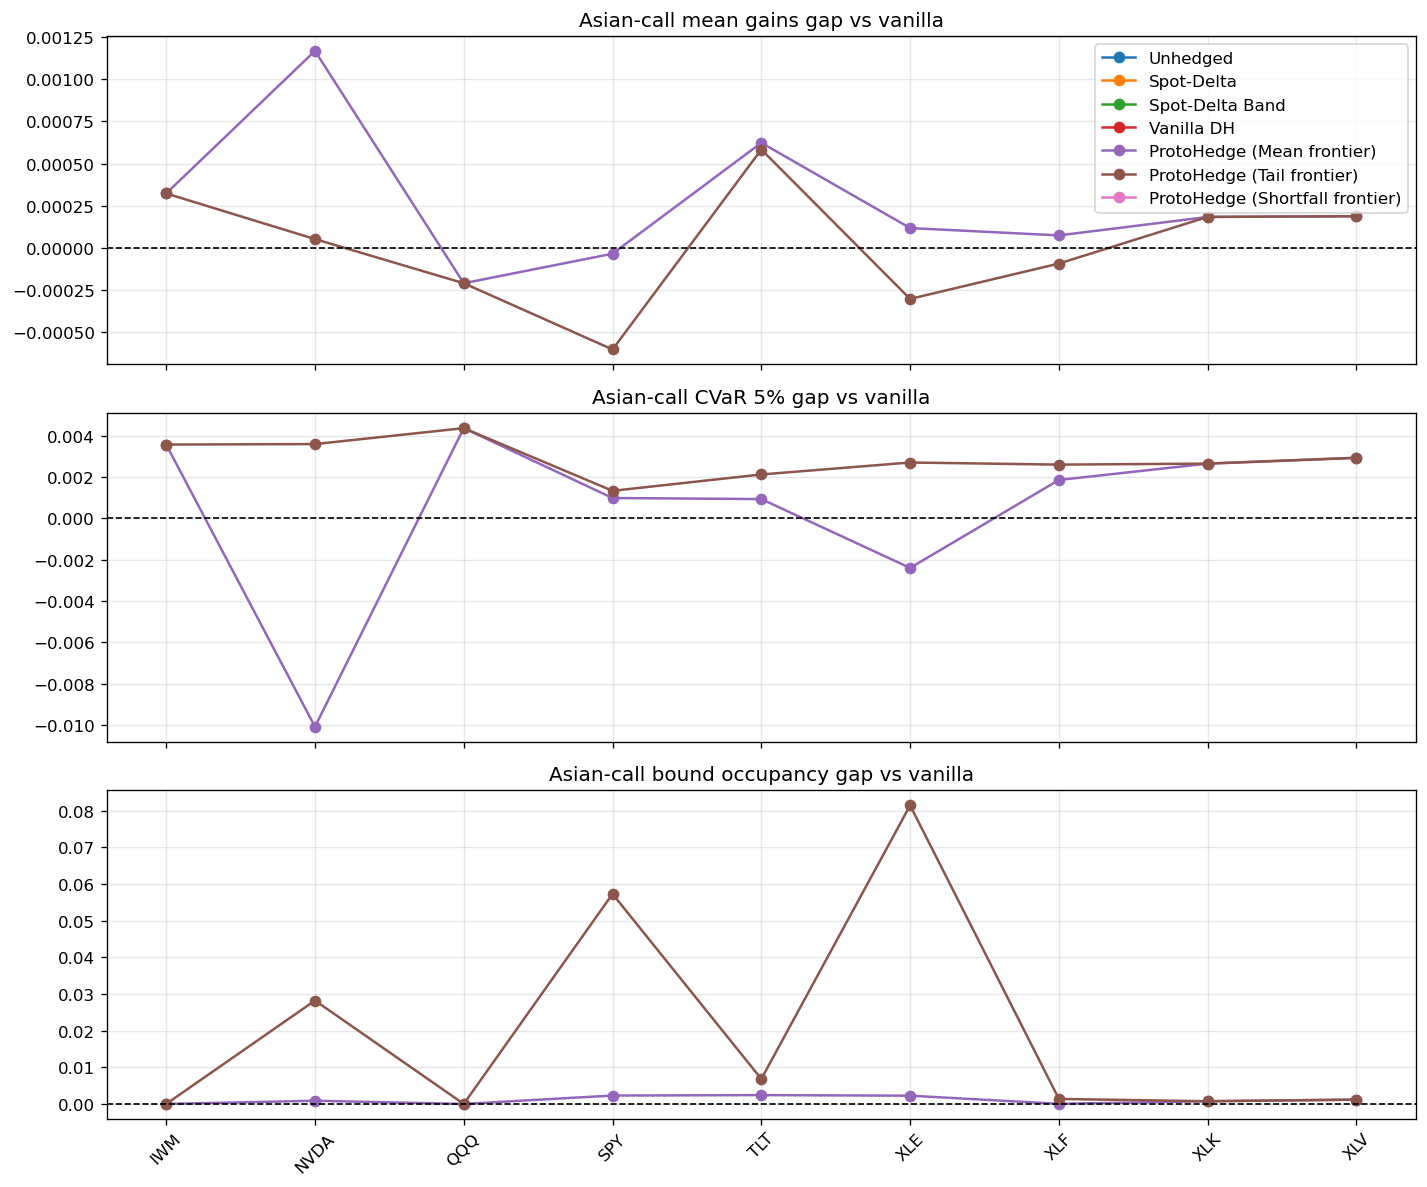

In [7]:

def metric_heatmap(df, metric, title, fmt='.3f', cmap='viridis'):
    pivot = df.pivot(index='ticker', columns='paper_label', values=metric)
    plt.figure(figsize=(12, max(4, 0.45 * len(pivot))))
    sns.heatmap(pivot, annot=True, fmt=fmt, cmap=cmap)
    plt.title(title)
    plt.tight_layout()
    return pivot

paper_subset = panel_df[panel_df['paper_label'].isin(PANEL_PAPER_LABEL_ORDER[:6])].copy()
mean_pivot = metric_heatmap(paper_subset, 'gains_mean_avg', 'Asian-call mean gains by ticker and model', fmt='.3f', cmap='viridis')
save_current_figure('asian_panel_mean_heatmap', subdir=ASIAN_PANEL_SUBDIR)
plt.show()

cvar_pivot = metric_heatmap(paper_subset, 'gains_cvar05_avg', 'Asian-call CVaR 5% by ticker and model', fmt='.3f', cmap='magma')
save_current_figure('asian_panel_cvar_heatmap', subdir=ASIAN_PANEL_SUBDIR)
plt.show()

bound_pivot = metric_heatmap(paper_subset, 'pct_at_any_position_bound_avg', 'Asian-call bound occupancy by ticker and model', fmt='.2f', cmap='rocket_r')
save_current_figure('asian_panel_bound_heatmap', subdir=ASIAN_PANEL_SUBDIR)
plt.show()

vanilla = paper_subset[paper_subset['paper_label'] == 'Vanilla DH'][['ticker', 'gains_mean_avg', 'gains_cvar05_avg', 'pct_at_any_position_bound_avg']].rename(
    columns={
        'gains_mean_avg': 'vanilla_mean',
        'gains_cvar05_avg': 'vanilla_cvar',
        'pct_at_any_position_bound_avg': 'vanilla_bound',
    }
)
proto_gap = paper_subset[paper_subset['paper_label'].isin(['ProtoHedge (Mean frontier)', 'ProtoHedge (Tail frontier)'])].merge(vanilla, on='ticker', how='left')
proto_gap['mean_gap_vs_vanilla'] = proto_gap['gains_mean_avg'] - proto_gap['vanilla_mean']
proto_gap['cvar_gap_vs_vanilla'] = proto_gap['gains_cvar05_avg'] - proto_gap['vanilla_cvar']
proto_gap['bound_gap_vs_vanilla'] = proto_gap['pct_at_any_position_bound_avg'] - proto_gap['vanilla_bound']
proto_gap.to_csv(PANEL_SUMMARY_DIR / 'panel_proto_vs_vanilla_gaps.csv', index=False)

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
for ax, col, title in [
    (axes[0], 'mean_gap_vs_vanilla', 'Asian-call mean gains gap vs vanilla'),
    (axes[1], 'cvar_gap_vs_vanilla', 'Asian-call CVaR 5% gap vs vanilla'),
    (axes[2], 'bound_gap_vs_vanilla', 'Asian-call bound occupancy gap vs vanilla'),
]:
    for label, grp in proto_gap.groupby('paper_label'):
        ax.plot(grp['ticker'], grp[col], marker='o', label=label)
    ax.axhline(0.0, color='black', linewidth=1, linestyle='--')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
axes[0].legend()
plt.xticks(rotation=45)
plt.tight_layout()
save_current_figure('asian_panel_proto_vs_vanilla_gaps', subdir=ASIAN_PANEL_SUBDIR)
plt.show()


In [8]:

panel_main = paper_subset[['ticker', 'paper_label', 'gains_mean_avg', 'gains_mean_std', 'gains_cvar05_avg', 'shortfall_prob_avg', 'pct_at_any_position_bound_avg', 'passes_robust_screen']].copy()
save_dataframe(panel_main, 'asian_panel_main_table', subdir=f'{ASIAN_PANEL_SUBDIR}/tables', latex=True, index=False)

def avg_table(df):
    rows = []
    for label, grp in df.groupby('paper_label', observed=True):
        rows.append({
            'paper_label': label,
            'mean_gains_avg': grp['gains_mean_avg'].mean(),
            'mean_gains_std_across_tickers': grp['gains_mean_avg'].std(ddof=0),
            'cvar05_avg': grp['gains_cvar05_avg'].mean(),
            'shortfall_avg': grp['shortfall_prob_avg'].mean(),
            'bound_occupancy_avg': grp['pct_at_any_position_bound_avg'].mean(),
            'n_tickers': grp['ticker'].nunique(),
        })
    out = pd.DataFrame(rows)
    out['paper_label'] = pd.Categorical(out['paper_label'], PANEL_PAPER_LABEL_ORDER, ordered=True)
    return out.sort_values('paper_label').reset_index(drop=True)

panel_average_table = avg_table(paper_subset)
save_dataframe(panel_average_table, 'asian_panel_average_table', subdir=f'{ASIAN_PANEL_SUBDIR}/tables', latex=True, index=False)

def rank_by_ticker(df, metric, ascending):
    ranked = []
    for ticker, grp in df.groupby('ticker'):
        sub = grp[['ticker', 'paper_label', metric]].copy()
        sub['rank'] = sub[metric].rank(ascending=ascending, method='min')
        sub['metric'] = metric
        ranked.append(sub)
    return pd.concat(ranked, ignore_index=True)

rank_mean = rank_by_ticker(paper_subset, 'gains_mean_avg', ascending=False)
rank_cvar = rank_by_ticker(paper_subset, 'gains_cvar05_avg', ascending=False)
rank_bound = rank_by_ticker(paper_subset, 'pct_at_any_position_bound_avg', ascending=True)
rank_df = pd.concat([rank_mean, rank_cvar, rank_bound], ignore_index=True)
rank_summary = rank_df.groupby(['paper_label', 'metric'], observed=True)['rank'].mean().reset_index()
save_dataframe(rank_summary, 'asian_panel_average_rank_table', subdir=f'{ASIAN_PANEL_SUBDIR}/tables', latex=True, index=False)

winner_rows = []
for ticker, grp in paper_subset.groupby('ticker'):
    winner_rows.append({
        'ticker': ticker,
        'best_mean_model': grp.sort_values('gains_mean_avg', ascending=False).iloc[0]['paper_label'],
        'best_cvar_model': grp.sort_values('gains_cvar05_avg', ascending=False).iloc[0]['paper_label'],
        'lowest_bound_model': grp.sort_values('pct_at_any_position_bound_avg', ascending=True).iloc[0]['paper_label'],
    })
winner_table = pd.DataFrame(winner_rows).sort_values('ticker').reset_index(drop=True)
save_dataframe(winner_table, 'asian_panel_winner_table', subdir=f'{ASIAN_PANEL_SUBDIR}/tables', latex=True, index=False)

summary_rows = []
van = paper_subset[paper_subset['paper_label'] == 'Vanilla DH'].set_index('ticker')
for proto_label in ['ProtoHedge (Mean frontier)', 'ProtoHedge (Tail frontier)']:
    sub = paper_subset[paper_subset['paper_label'] == proto_label].set_index('ticker')
    common = sub.index.intersection(van.index)
    tmp = sub.loc[common].copy()
    tmp['vanilla_mean'] = van.loc[common, 'gains_mean_avg']
    tmp['vanilla_cvar'] = van.loc[common, 'gains_cvar05_avg']
    tmp['vanilla_bound'] = van.loc[common, 'pct_at_any_position_bound_avg']
    summary_rows.append({
        'proto_label': proto_label,
        'n_tickers': len(common),
        'wins_mean': int((tmp['gains_mean_avg'] > tmp['vanilla_mean']).sum()),
        'wins_cvar': int((tmp['gains_cvar05_avg'] > tmp['vanilla_cvar']).sum()),
        'lower_bound_occupancy': int((tmp['pct_at_any_position_bound_avg'] < tmp['vanilla_bound']).sum()),
        'avg_mean_gap_vs_vanilla': float((tmp['gains_mean_avg'] - tmp['vanilla_mean']).mean()),
        'avg_cvar_gap_vs_vanilla': float((tmp['gains_cvar05_avg'] - tmp['vanilla_cvar']).mean()),
        'avg_bound_gap_vs_vanilla': float((tmp['pct_at_any_position_bound_avg'] - tmp['vanilla_bound']).mean()),
    })
proto_vs_vanilla_summary = pd.DataFrame(summary_rows)
save_dataframe(proto_vs_vanilla_summary, 'asian_panel_proto_vs_vanilla_summary', subdir=f'{ASIAN_PANEL_SUBDIR}/tables', latex=True, index=False)

display(panel_average_table)
display(rank_summary)
display(winner_table)
display(proto_vs_vanilla_summary)


saved table: /Users/yaniszaim/deephedging/paper/final_notebook_assets/asian_real_data_panel/tables/asian_panel_main_table.csv
saved latex: /Users/yaniszaim/deephedging/paper/final_notebook_assets/asian_real_data_panel/tables/asian_panel_main_table.tex
saved table: /Users/yaniszaim/deephedging/paper/final_notebook_assets/asian_real_data_panel/tables/asian_panel_average_table.csv
saved latex: /Users/yaniszaim/deephedging/paper/final_notebook_assets/asian_real_data_panel/tables/asian_panel_average_table.tex
saved table: /Users/yaniszaim/deephedging/paper/final_notebook_assets/asian_real_data_panel/tables/asian_panel_average_rank_table.csv
saved latex: /Users/yaniszaim/deephedging/paper/final_notebook_assets/asian_real_data_panel/tables/asian_panel_average_rank_table.tex
saved table: /Users/yaniszaim/deephedging/paper/final_notebook_assets/asian_real_data_panel/tables/asian_panel_winner_table.csv
saved latex: /Users/yaniszaim/deephedging/paper/final_notebook_assets/asian_real_data_panel/ta

,paper_label,mean_gains_avg,mean_gains_std_across_tickers,cvar05_avg,shortfall_avg,bound_occupancy_avg,n_tickers
0,Unhedged,-0.016479,0.007969,-0.078681,0.594767,0.000000,10
1,Spot-Delta,-0.016265,0.007606,-0.074999,0.811725,0.000000,10
2,Spot-Delta Band,-0.016240,0.007595,-0.074893,0.817611,0.000000,10
3,Vanilla DH,-0.015801,0.008071,-0.074384,0.952370,0.018519,9
4,ProtoHedge (Mean frontier),-0.015530,0.007812,-0.073844,0.882050,0.019606,9
5,ProtoHedge (Tail frontier),-0.015786,0.008105,-0.071501,0.914211,0.038187,9


,paper_label,metric,rank
0,Unhedged,gains_cvar05_avg,5.700000
1,Unhedged,gains_mean_avg,4.700000
2,Unhedged,pct_at_any_position_bound_avg,1.000000
3,Spot-Delta,gains_cvar05_avg,3.600000
4,Spot-Delta,gains_mean_avg,4.000000
5,Spot-Delta,pct_at_any_position_bound_avg,1.000000
6,Spot-Delta Band,gains_cvar05_avg,3.500000
7,Spot-Delta Band,gains_mean_avg,3.500000
8,Spot-Delta Band,pct_at_any_position_bound_avg,1.000000
9,Vanilla DH,gains_cvar05_avg,3.666667


,ticker,best_mean_model,best_cvar_model,lowest_bound_model
0,AAPL,Spot-Delta,Spot-Delta Band,Unhedged
1,IWM,ProtoHedge (Mean frontier),ProtoHedge (Mean frontier),Unhedged
2,NVDA,ProtoHedge (Mean frontier),ProtoHedge (Tail frontier),Unhedged
3,QQQ,Vanilla DH,ProtoHedge (Mean frontier),Unhedged
4,SPY,Vanilla DH,ProtoHedge (Tail frontier),Unhedged
5,TLT,ProtoHedge (Mean frontier),ProtoHedge (Tail frontier),Unhedged
6,XLE,ProtoHedge (Mean frontier),ProtoHedge (Tail frontier),Unhedged
7,XLF,Spot-Delta Band,ProtoHedge (Tail frontier),Unhedged
8,XLK,ProtoHedge (Mean frontier),ProtoHedge (Mean frontier),Unhedged
9,XLV,ProtoHedge (Mean frontier),ProtoHedge (Mean frontier),Unhedged


,proto_label,n_tickers,wins_mean,wins_cvar,lower_bound_occupancy,avg_mean_gap_vs_vanilla,avg_cvar_gap_vs_vanilla,avg_bound_gap_vs_vanilla
0,ProtoHedge (Mean frontier),9,7,7,0,0.000271,0.000541,0.001087
1,ProtoHedge (Tail frontier),9,5,9,0,0.000015,0.002883,0.019669


saved figure: /Users/yaniszaim/deephedging/paper/final_notebook_assets/asian_real_data_panel/asian_panel_frontier_and_bound_scatter_3.png


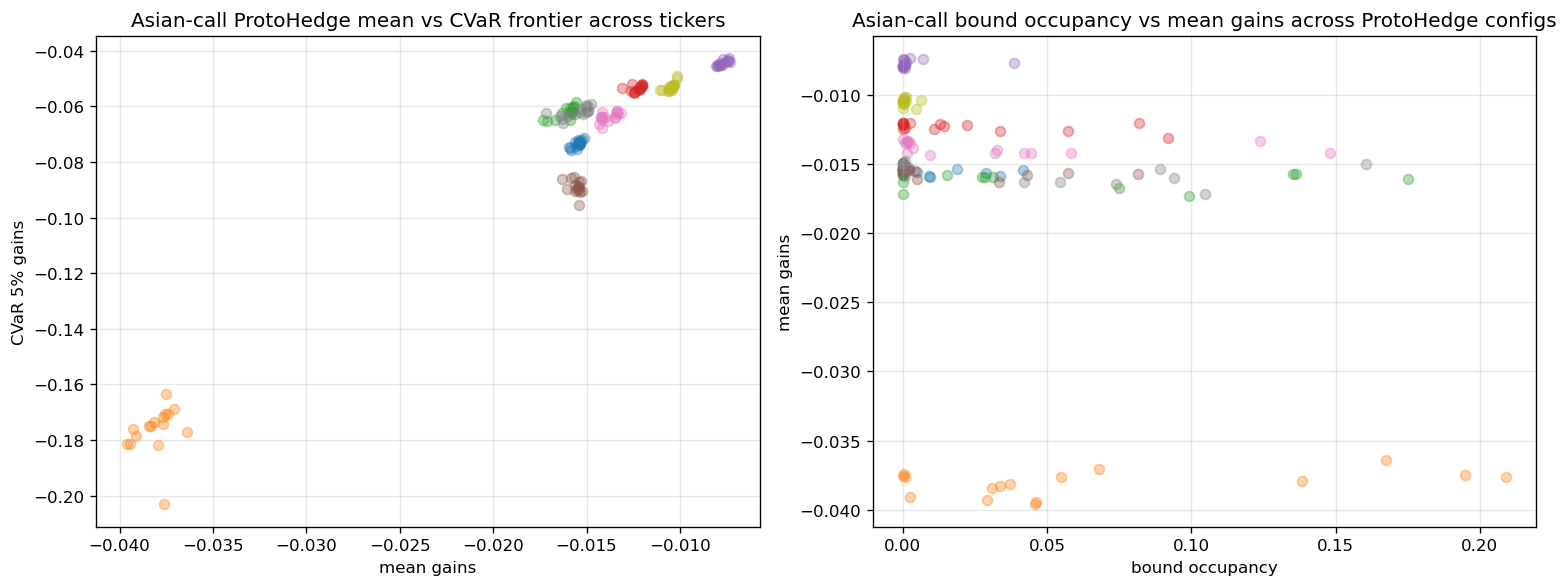

In [9]:

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
proto_points = panel_all_models_df[panel_all_models_df['model_family'] == 'proto'].copy()
for ticker, grp in proto_points.groupby('ticker'):
    axes[0].scatter(grp['gains_mean_avg'], grp['gains_cvar05_avg'], alpha=0.35, label=ticker)
axes[0].set_title('Asian-call ProtoHedge mean vs CVaR frontier across tickers')
axes[0].set_xlabel('mean gains')
axes[0].set_ylabel('CVaR 5% gains')
axes[0].grid(True, alpha=0.3)

for ticker, grp in proto_points.groupby('ticker'):
    axes[1].scatter(grp['pct_at_any_position_bound_avg'], grp['gains_mean_avg'], alpha=0.35, label=ticker)
axes[1].set_title('Asian-call bound occupancy vs mean gains across ProtoHedge configs')
axes[1].set_xlabel('bound occupancy')
axes[1].set_ylabel('mean gains')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
save_current_figure('asian_panel_frontier_and_bound_scatter', subdir=ASIAN_PANEL_SUBDIR)
plt.show()


## Deep Dive: Representative Ticker

This section reproduces the regime and interpretability analysis for a representative Asian-call ticker, using the selected ProtoHedge tail frontier.


In [10]:

out_dir, comp, best, artifact_index = load_panel_outputs_for_ticker(DEEP_DIVE_TICKER)
best_row = select_best_row(best, DEEP_DIVE_SELECTION, fallback_selections=('best_proto_cvar05', 'best_cvar05'))
TARGET_MODEL = str(best_row['model'])
print('deep dive ticker:', DEEP_DIVE_TICKER)
print('selection:', DEEP_DIVE_SELECTION)
print('target model:', TARGET_MODEL)

artifact_rows = artifact_index[(artifact_index['model_name'] == TARGET_MODEL) & (artifact_index['risk_measure'] == 'cvar')].copy()
if 'seed' in artifact_rows.columns and DEEP_DIVE_SEED in artifact_rows['seed'].tolist():
    artifact_dir = Path(artifact_rows[artifact_rows['seed'] == DEEP_DIVE_SEED].iloc[0]['artifact_dir'])
else:
    artifact_dir = Path(artifact_rows.iloc[0]['artifact_dir'])
print('artifact:', artifact_dir)

bundle, proto_result, proto_metrics = evaluate_saved_artifact(artifact_dir, split='test')
baselines = evaluate_saved_baselines(artifact_dir, split='test')
vanilla_rows = artifact_index[(artifact_index['model_name'] == 'vanilla') & (artifact_index['risk_measure'] == 'cvar')].copy()
vanilla_artifact_dir = Path(vanilla_rows[vanilla_rows['seed'] == DEEP_DIVE_SEED].iloc[0]['artifact_dir']) if DEEP_DIVE_SEED in vanilla_rows['seed'].tolist() else Path(vanilla_rows.iloc[0]['artifact_dir'])
vanilla_bundle, vanilla_result, vanilla_metrics = evaluate_saved_artifact(vanilla_artifact_dir, split='test')

result_dict = {
    'proto': proto_result,
    'vanilla': vanilla_result,
    'spot_delta_band': baselines['spot_delta_band']['result'],
    'unhedged': baselines['unhedged']['result'],
}
regime_frame = build_regime_frame(bundle['eval_world'], result_dict)
regime_summary = pd.concat([
    summarize_by_regime(regime_frame, 'return_regime'),
    summarize_by_regime(regime_frame, 'vol_regime'),
    summarize_by_regime(regime_frame, 'drawdown_regime'),
], axis=0, ignore_index=True)
regime_summary.to_csv(PANEL_SUMMARY_DIR / f'{DEEP_DIVE_TICKER}_regime_summary.csv', index=False)
save_dataframe(regime_summary, f'{DEEP_DIVE_TICKER.lower()}_asian_regime_summary', subdir=f'{ASIAN_PANEL_SUBDIR}/tables', latex=False, index=False)
display(regime_summary.head())


deep dive ticker: QQQ
selection: best_screened_proto_cvar05
target model: proto_source=spot_delta_k=50_weighted=0_learnw=0
artifact: /Users/yaniszaim/deephedging/.deephedging_real_runs/final_paper_asian_panel/panel_sweeps/QQQ_full_paper_grid_800_asian_call_step_robust/model_artifacts/seed_1234/risk_cvar/proto_source_spot_delta_k_50_weighted_0_learnw_0
saved table: /Users/yaniszaim/deephedging/paper/final_notebook_assets/asian_real_data_panel/tables/qqq_asian_regime_summary.csv


,regime_type,regime,series,n,mean,p05,cvar05,shortfall_prob
0,return_regime,down,proto_gains,170,-0.004055,-0.013226,-0.020060,0.811765
1,return_regime,down,vanilla_gains,170,-0.004203,-0.015531,-0.022552,0.988235
2,return_regime,down,spot_delta_band_gains,170,-0.003694,-0.019781,-0.022995,0.717647
3,return_regime,down,unhedged_gains,170,-0.002596,-0.015457,-0.021962,0.264706
4,return_regime,middle,proto_gains,169,-0.012027,-0.026697,-0.029942,0.988166


saved figure: /Users/yaniszaim/deephedging/paper/final_notebook_assets/asian_real_data_panel/qqq_asian_return_regime_mean.png


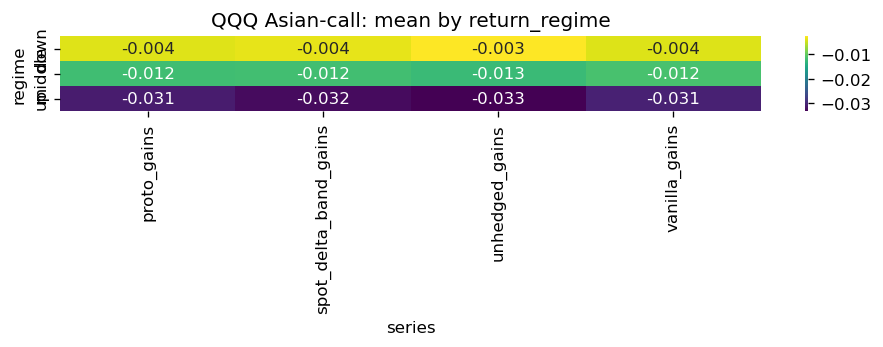

saved figure: /Users/yaniszaim/deephedging/paper/final_notebook_assets/asian_real_data_panel/qqq_asian_return_regime_cvar05.png


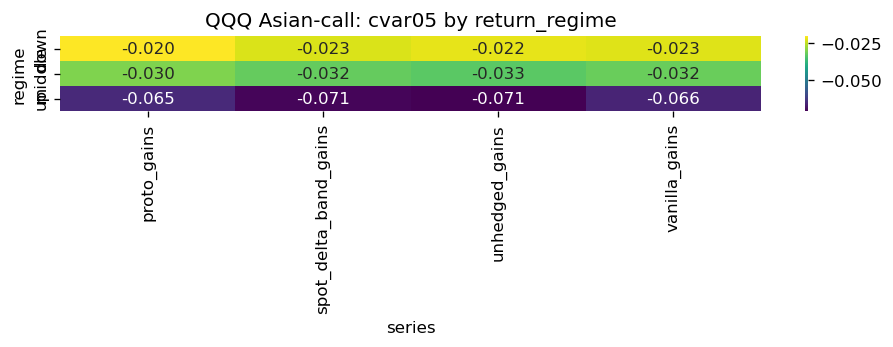

saved figure: /Users/yaniszaim/deephedging/paper/final_notebook_assets/asian_real_data_panel/qqq_asian_return_regime_shortfall_prob.png


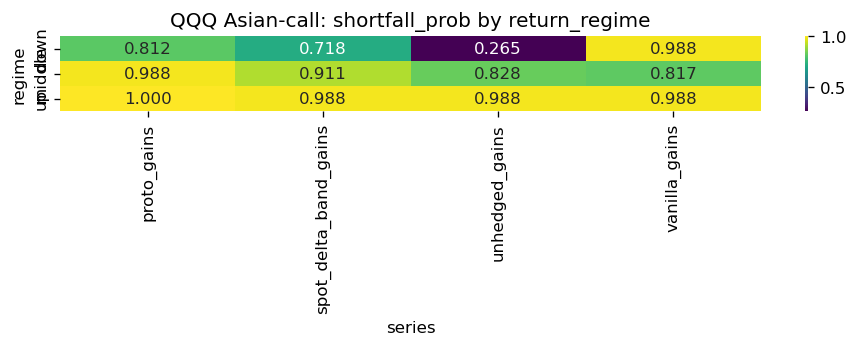

saved figure: /Users/yaniszaim/deephedging/paper/final_notebook_assets/asian_real_data_panel/qqq_asian_vol_regime_mean.png


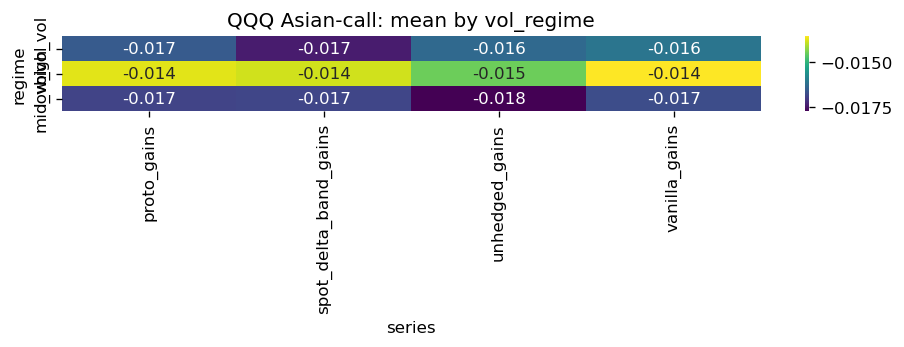

saved figure: /Users/yaniszaim/deephedging/paper/final_notebook_assets/asian_real_data_panel/qqq_asian_vol_regime_cvar05.png


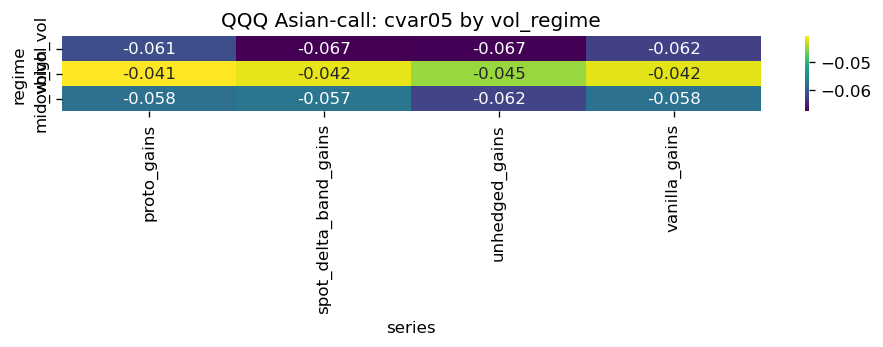

saved figure: /Users/yaniszaim/deephedging/paper/final_notebook_assets/asian_real_data_panel/qqq_asian_vol_regime_shortfall_prob.png


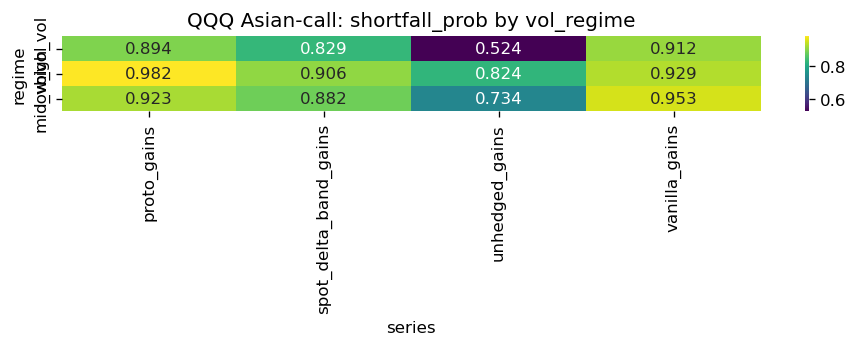

saved figure: /Users/yaniszaim/deephedging/paper/final_notebook_assets/asian_real_data_panel/qqq_asian_drawdown_regime_mean.png


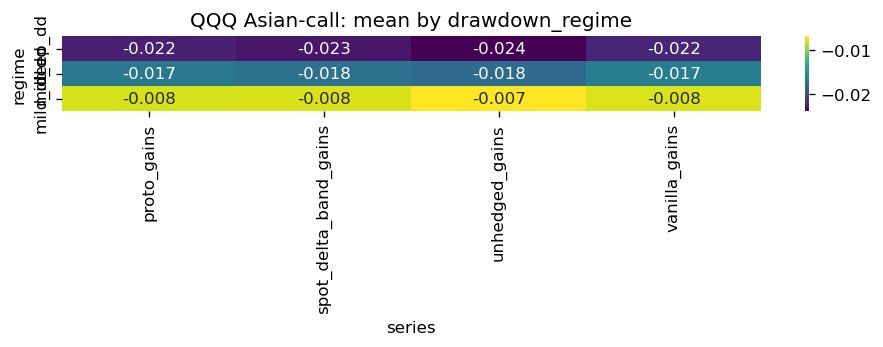

saved figure: /Users/yaniszaim/deephedging/paper/final_notebook_assets/asian_real_data_panel/qqq_asian_drawdown_regime_cvar05.png


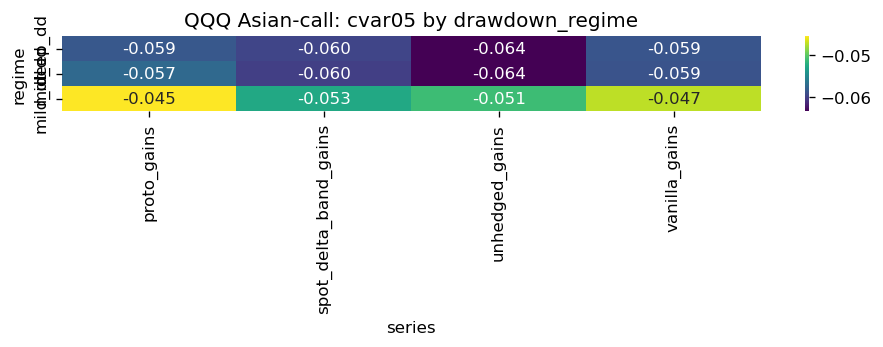

saved figure: /Users/yaniszaim/deephedging/paper/final_notebook_assets/asian_real_data_panel/qqq_asian_drawdown_regime_shortfall_prob.png


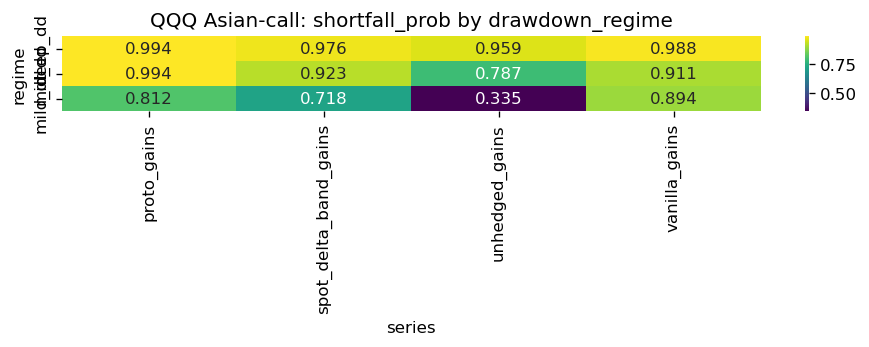

In [11]:

for regime_type in ['return_regime', 'vol_regime', 'drawdown_regime']:
    sub = regime_summary[regime_summary['regime_type'] == regime_type].copy()
    for metric in ['mean', 'cvar05', 'shortfall_prob']:
        pivot = sub.pivot(index='regime', columns='series', values=metric)
        plt.figure(figsize=(8, 3))
        sns.heatmap(pivot, annot=True, fmt='.3f', cmap='viridis')
        plt.title(f'{DEEP_DIVE_TICKER} Asian-call: {metric} by {regime_type}')
        plt.tight_layout()
        save_current_figure(f'{DEEP_DIVE_TICKER.lower()}_asian_{regime_type}_{metric}', subdir=ASIAN_PANEL_SUBDIR)
        plt.show()


saved table: /Users/yaniszaim/deephedging/paper/final_notebook_assets/asian_real_data_panel/tables/qqq_asian_prototype_top10.csv
saved latex: /Users/yaniszaim/deephedging/paper/final_notebook_assets/asian_real_data_panel/tables/qqq_asian_prototype_top10.tex
saved table: /Users/yaniszaim/deephedging/paper/final_notebook_assets/asian_real_data_panel/tables/qqq_asian_prototype_usage_by_regime.csv


,prototype_index,usage_mean,top1_frequency,delta_0,delta_1,price_0,price_1,time_left,proto_action_0,proto_action_1
0,10,0.198709,0.208743,0.510199,0.0,1.004545,0.016447,0.06,0.133258,-0.000052
1,34,0.077528,0.171709,0.504026,0.0,0.999854,0.015618,0.20,-0.005609,0.000884
2,32,0.075340,0.046955,0.530124,0.0,1.012525,0.035929,0.08,-0.022542,0.003134
3,8,0.066472,0.128291,0.518933,0.0,1.044130,0.019632,0.06,0.039634,-0.003863
4,16,0.062201,0.070039,0.533406,0.0,1.009637,0.023888,0.06,0.020739,-0.002228
5,6,0.060544,0.095580,0.515654,0.0,0.979780,0.026911,0.10,0.011032,0.024944
6,0,0.050452,0.022102,0.504053,0.0,1.014330,0.013020,0.14,0.104032,0.002950
7,41,0.050229,0.052554,0.528509,0.0,1.025699,0.019169,0.14,-0.019885,0.005709
8,38,0.035786,0.020629,0.513168,0.0,1.041253,0.027115,0.10,-0.038710,0.015427
9,23,0.035478,0.042141,0.528770,0.0,0.945039,0.036567,0.08,-0.041551,-0.008902


saved figure: /Users/yaniszaim/deephedging/paper/final_notebook_assets/asian_real_data_panel/qqq_asian_top_prototype_usage.png


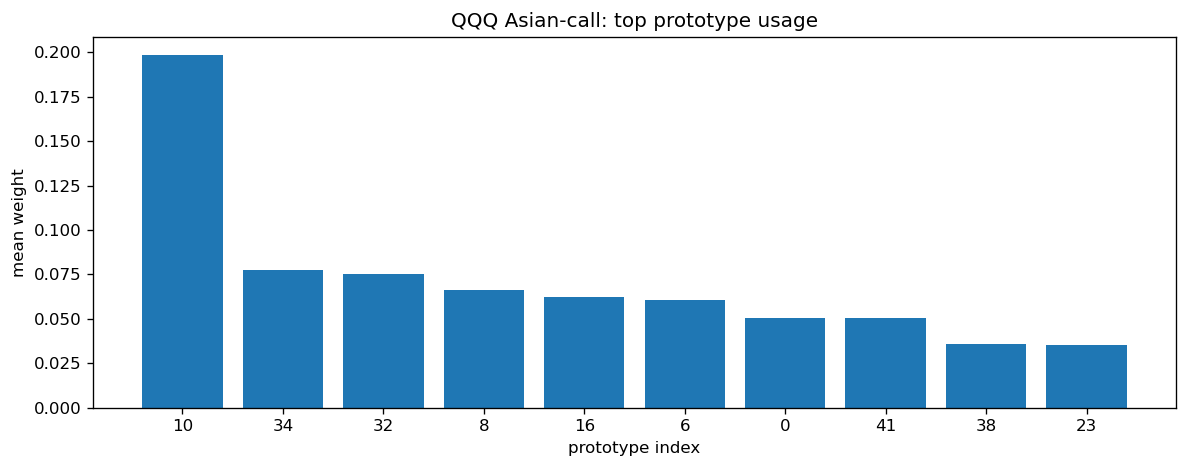

saved figure: /Users/yaniszaim/deephedging/paper/final_notebook_assets/asian_real_data_panel/qqq_asian_return_regime_prototype_usage.png


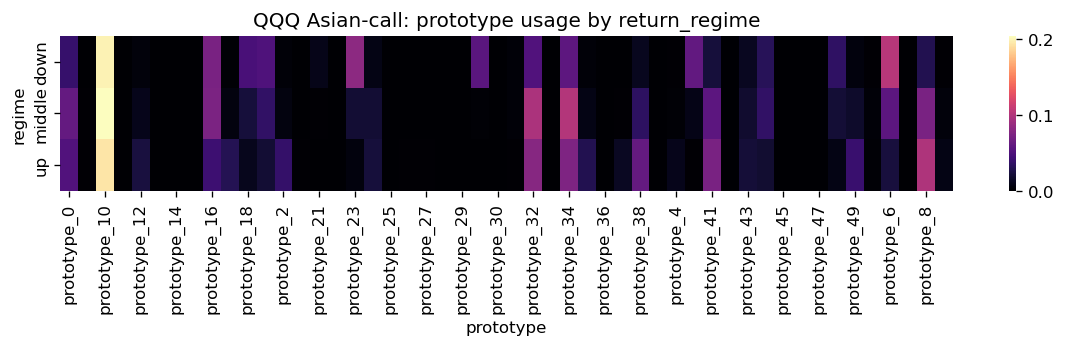

saved figure: /Users/yaniszaim/deephedging/paper/final_notebook_assets/asian_real_data_panel/qqq_asian_vol_regime_prototype_usage.png


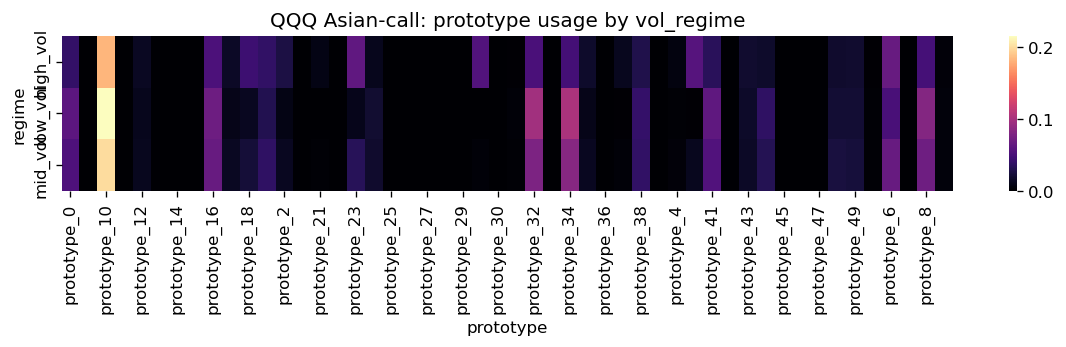

saved figure: /Users/yaniszaim/deephedging/paper/final_notebook_assets/asian_real_data_panel/qqq_asian_drawdown_regime_prototype_usage.png


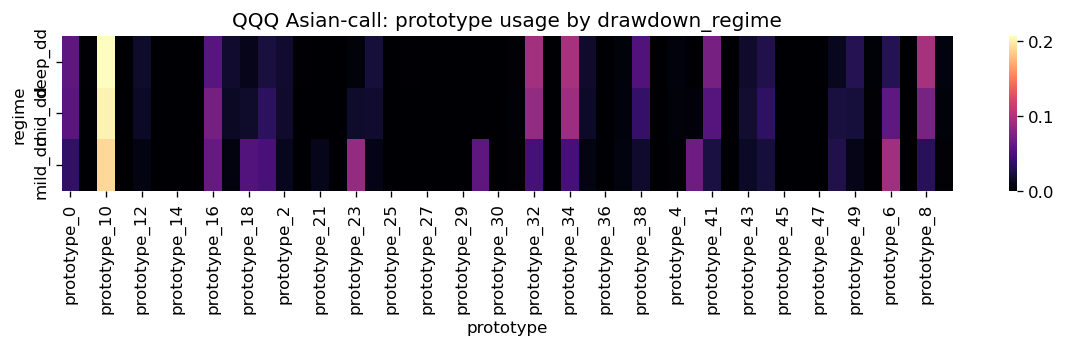

In [12]:

top_proto_df, full_proto_df = prototype_usage_table(bundle, proto_result, top_n=10)
usage_by_regime_df = prototype_usage_by_regime(proto_result, regime_frame)
save_dataframe(top_proto_df, f'{DEEP_DIVE_TICKER.lower()}_asian_prototype_top10', subdir=f'{ASIAN_PANEL_SUBDIR}/tables', latex=True, index=False)
save_dataframe(usage_by_regime_df, f'{DEEP_DIVE_TICKER.lower()}_asian_prototype_usage_by_regime', subdir=f'{ASIAN_PANEL_SUBDIR}/tables', latex=False, index=False)
display(top_proto_df)

plt.figure(figsize=(10, 4))
plot_df = top_proto_df.sort_values('usage_mean', ascending=False).head(10)
plt.bar(plot_df['prototype_index'].astype(str), plot_df['usage_mean'])
plt.title(f'{DEEP_DIVE_TICKER} Asian-call: top prototype usage')
plt.xlabel('prototype index')
plt.ylabel('mean weight')
plt.tight_layout()
save_current_figure(f'{DEEP_DIVE_TICKER.lower()}_asian_top_prototype_usage', subdir=ASIAN_PANEL_SUBDIR)
plt.show()

for regime_type in ['return_regime', 'vol_regime', 'drawdown_regime']:
    sub = usage_by_regime_df[usage_by_regime_df['regime_type'] == regime_type].copy()
    pivot = sub.pivot(index='regime', columns='prototype', values='mean_weight')
    plt.figure(figsize=(10, 3))
    sns.heatmap(pivot, annot=False, cmap='magma')
    plt.title(f'{DEEP_DIVE_TICKER} Asian-call: prototype usage by {regime_type}')
    plt.tight_layout()
    save_current_figure(f'{DEEP_DIVE_TICKER.lower()}_asian_{regime_type}_prototype_usage', subdir=ASIAN_PANEL_SUBDIR)
    plt.show()


saved table: /Users/yaniszaim/deephedging/paper/final_notebook_assets/asian_real_data_panel/tables/qqq_asian_prototype_concentration_table.csv
saved latex: /Users/yaniszaim/deephedging/paper/final_notebook_assets/asian_real_data_panel/tables/qqq_asian_prototype_concentration_table.tex
saved figure: /Users/yaniszaim/deephedging/paper/final_notebook_assets/asian_real_data_panel/qqq_asian_prototype_concentration.png


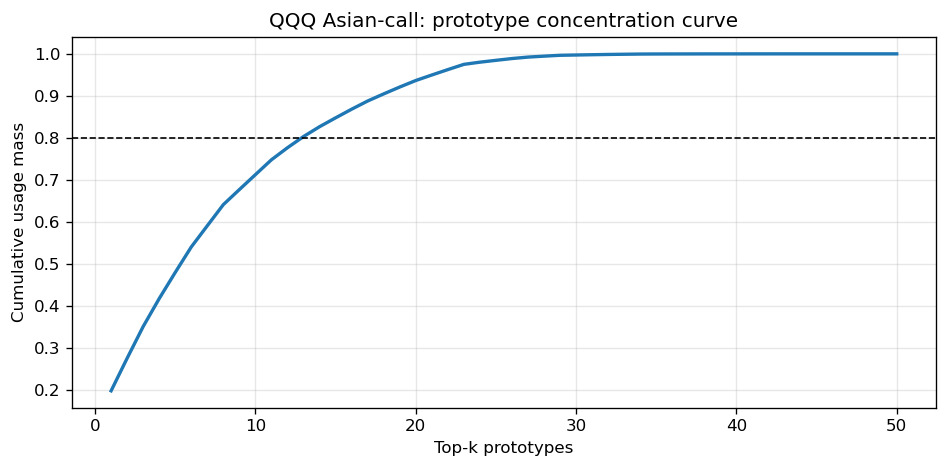

In [13]:

usage_sorted = full_proto_df.sort_values('usage_mean', ascending=False).reset_index(drop=True).copy()
usage_sorted['cum_usage_mean'] = usage_sorted['usage_mean'].cumsum()
usage_sorted['k'] = np.arange(1, len(usage_sorted) + 1)
save_dataframe(usage_sorted[['k', 'prototype_index', 'usage_mean', 'cum_usage_mean']].head(50), f'{DEEP_DIVE_TICKER.lower()}_asian_prototype_concentration_table', subdir=f'{ASIAN_PANEL_SUBDIR}/tables', latex=True, index=False)

plt.figure(figsize=(8, 4))
plt.plot(usage_sorted['k'], usage_sorted['cum_usage_mean'], linewidth=2)
plt.axhline(0.8, color='black', linestyle='--', linewidth=1)
plt.xlabel('Top-k prototypes')
plt.ylabel('Cumulative usage mass')
plt.title(f'{DEEP_DIVE_TICKER} Asian-call: prototype concentration curve')
plt.grid(True, alpha=0.3)
plt.tight_layout()
save_current_figure(f'{DEEP_DIVE_TICKER.lower()}_asian_prototype_concentration', subdir=ASIAN_PANEL_SUBDIR)
plt.show()


saved table: /Users/yaniszaim/deephedging/paper/final_notebook_assets/asian_real_data_panel/tables/qqq_asian_nearest_prototype_states.csv
saved latex: /Users/yaniszaim/deephedging/paper/final_notebook_assets/asian_real_data_panel/tables/qqq_asian_nearest_prototype_states.tex


,prototype_index,nearest_rank,distance_scaled,path_index,step_index,delta_0,delta_1,price_0,price_1,time_left
0,8,1,0.107956,235,4,0.509708,0.000166,1.042972,0.019153,0.063492
1,8,2,0.207333,301,4,0.519494,0.000491,1.043954,0.017913,0.063492
2,8,3,0.211738,219,8,0.526067,0.001128,1.045076,0.021054,0.047619
3,10,1,0.096180,54,4,0.519688,0.001288,1.004012,0.016749,0.063492
4,10,2,0.104238,383,4,0.514459,0.001843,1.006567,0.017064,0.063492
5,10,3,0.110539,482,4,0.520285,0.001204,1.006592,0.016608,0.063492
6,32,1,0.250048,119,6,0.524990,0.003650,1.010315,0.036841,0.055556
7,32,2,0.287597,462,5,0.530851,0.001586,1.005198,0.036756,0.059524
8,32,3,0.291287,90,5,0.526372,0.006523,1.004465,0.036312,0.059524
9,34,1,1.194058,440,4,0.517547,0.001510,0.996122,0.015705,0.063492


saved figure: /Users/yaniszaim/deephedging/paper/final_notebook_assets/asian_real_data_panel/qqq_asian_nearest_historical_episodes.png


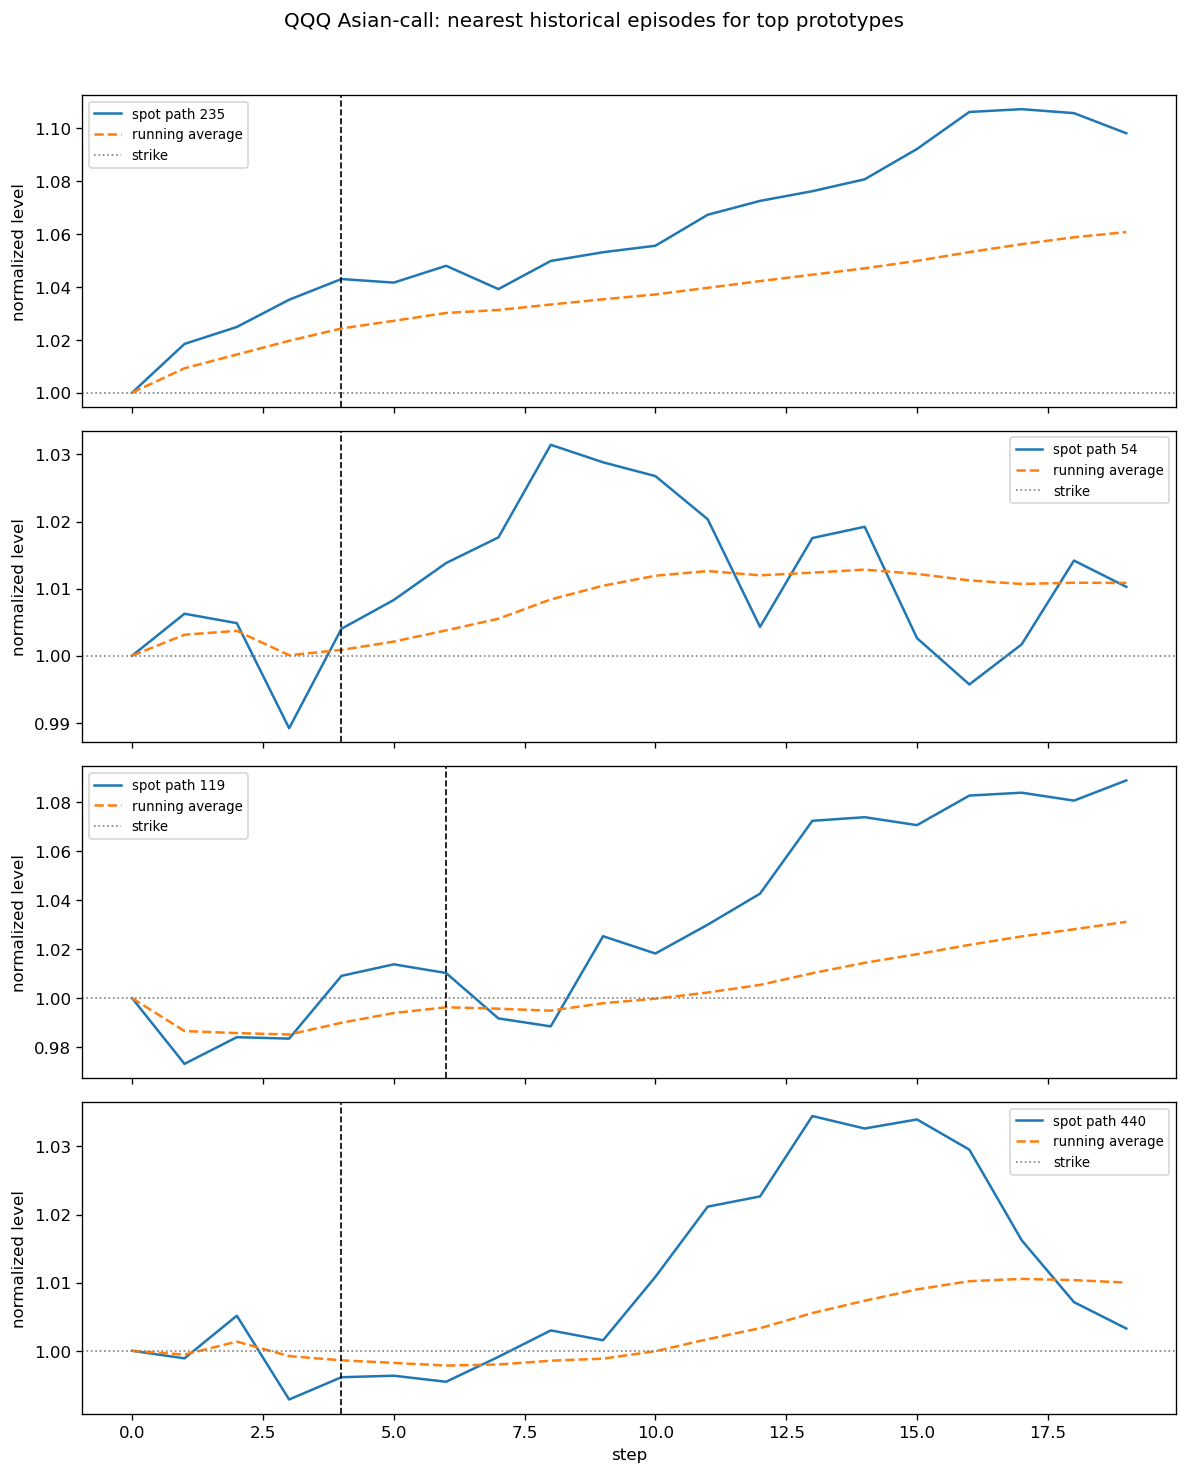

In [14]:

proto_path = bundle['metadata']['prototype_path']
payload = load_prototype_payload(proto_path)
prototypes_scaled = np.asarray(payload['prototypes'], dtype=np.float32)
scaler = payload['scaler']
feature_names = payload.get('feature_names', MODEL_FEATURES)

x_raw, feature_names_sorted = extract_agent_feature_matrix(
    world=bundle['eval_world'],
    result=proto_result,
    feature_names=feature_names,
)
x_scaled = scaler.transform(x_raw)
feature_cols = expanded_feature_cols(feature_names_sorted, bundle['eval_world'], x_raw.shape[1])

n_paths = int(bundle['eval_world'].data.market.hedges.shape[0])
n_steps = int(bundle['eval_world'].data.market.hedges.shape[1])

rows = []
for proto_idx in top_proto_df['prototype_index'].head(4).astype(int):
    dists = np.linalg.norm(x_scaled - prototypes_scaled[proto_idx], axis=1)
    nearest = np.argsort(dists)[:3]
    for rank, flat_idx in enumerate(nearest, start=1):
        path_idx = int(flat_idx // n_steps)
        step_idx = int(flat_idx % n_steps)
        row = {
            'prototype_index': int(proto_idx),
            'nearest_rank': int(rank),
            'distance_scaled': float(dists[flat_idx]),
            'path_index': path_idx,
            'step_index': step_idx,
        }
        for j, col in enumerate(feature_cols):
            row[col] = float(x_raw[flat_idx, j])
        rows.append(row)
nearest_proto_states_df = pd.DataFrame(rows).sort_values(['prototype_index', 'nearest_rank']).reset_index(drop=True)
save_dataframe(nearest_proto_states_df, f'{DEEP_DIVE_TICKER.lower()}_asian_nearest_prototype_states', subdir=f'{ASIAN_PANEL_SUBDIR}/tables', latex=True, index=False)
display(nearest_proto_states_df)

fig, axes = plt.subplots(min(4, len(nearest_proto_states_df['prototype_index'].unique())), 1, figsize=(10, 3.0 * min(4, len(nearest_proto_states_df['prototype_index'].unique()))), sharex=True)
if not isinstance(axes, np.ndarray):
    axes = np.array([axes])
for ax, proto_idx in zip(axes, nearest_proto_states_df['prototype_index'].drop_duplicates().tolist()[:4]):
    row = nearest_proto_states_df[nearest_proto_states_df['prototype_index'] == proto_idx].iloc[0]
    path_idx = int(row['path_index'])
    step_idx = int(row['step_index'])
    spot = np.asarray(bundle['eval_world'].data.features.per_step['spot'])[path_idx]
    running_avg = np.cumsum(spot) / (np.arange(len(spot)) + 1.0)
    strike = float(np.asarray(bundle['eval_world'].data.features.per_path['strike'])[path_idx, 0])
    ax.plot(np.arange(len(spot)), spot, label=f'spot path {path_idx}')
    ax.plot(np.arange(len(running_avg)), running_avg, label='running average', linestyle='--')
    ax.axhline(strike, color='gray', linestyle=':', linewidth=1, label='strike')
    ax.axvline(step_idx, color='black', linestyle='--', linewidth=1)
    ax.set_ylabel('normalized level')
    ax.legend(fontsize=8)
axes[-1].set_xlabel('step')
plt.suptitle(f'{DEEP_DIVE_TICKER} Asian-call: nearest historical episodes for top prototypes', y=1.02)
plt.tight_layout()
save_current_figure(f'{DEEP_DIVE_TICKER.lower()}_asian_nearest_historical_episodes', subdir=ASIAN_PANEL_SUBDIR)
plt.show()


In [15]:

for _, row in manifest.iterrows():
    out_dir = ticker_output_dir(row['ticker'])
    maybe_copy(out_dir / 'paper_model_comparison.csv', subdir=f'{ASIAN_PANEL_SUBDIR}/per_ticker_csv')
    maybe_copy(out_dir / 'paper_best_models.csv', subdir=f'{ASIAN_PANEL_SUBDIR}/per_ticker_csv')
    maybe_copy(out_dir / 'sweep_test_gains_mean.png', subdir=f'{ASIAN_PANEL_SUBDIR}/per_ticker_plots')
    maybe_copy(out_dir / 'sweep_test_cvar05.png', subdir=f'{ASIAN_PANEL_SUBDIR}/per_ticker_plots')
    maybe_copy(out_dir / 'sweep_test_shortfall_prob.png', subdir=f'{ASIAN_PANEL_SUBDIR}/per_ticker_plots')
    maybe_copy(out_dir / 'sweep_test_bound_saturation.png', subdir=f'{ASIAN_PANEL_SUBDIR}/per_ticker_plots')

asset_manifest = pd.DataFrame(sorted([str(p.relative_to(PAPER_ASSET_DIR)) for p in PAPER_ASSET_DIR.rglob('*') if p.is_file()]), columns=['asset'])
save_dataframe(asset_manifest, 'asian_final_asset_manifest', subdir='.', latex=False, index=False)
display(asset_manifest.head(100))


copied asset: /Users/yaniszaim/deephedging/paper/final_notebook_assets/asian_real_data_panel/per_ticker_csv/paper_model_comparison_2.csv
copied asset: /Users/yaniszaim/deephedging/paper/final_notebook_assets/asian_real_data_panel/per_ticker_csv/paper_best_models_2.csv
copied asset: /Users/yaniszaim/deephedging/paper/final_notebook_assets/asian_real_data_panel/per_ticker_plots/sweep_test_gains_mean_2.png
copied asset: /Users/yaniszaim/deephedging/paper/final_notebook_assets/asian_real_data_panel/per_ticker_plots/sweep_test_cvar05_2.png
copied asset: /Users/yaniszaim/deephedging/paper/final_notebook_assets/asian_real_data_panel/per_ticker_plots/sweep_test_shortfall_prob_2.png
copied asset: /Users/yaniszaim/deephedging/paper/final_notebook_assets/asian_real_data_panel/per_ticker_plots/sweep_test_bound_saturation_2.png
copied asset: /Users/yaniszaim/deephedging/paper/final_notebook_assets/asian_real_data_panel/per_ticker_csv/paper_model_comparison_3.csv
copied asset: /Users/yaniszaim/deeph

,asset
0,asian_final_asset_manifest.csv
1,asian_real_data_panel/asian_panel_bound_heatma...
2,asian_real_data_panel/asian_panel_bound_heatma...
3,asian_real_data_panel/asian_panel_bound_heatma...
4,asian_real_data_panel/asian_panel_cvar_heatmap...
...,...
95,asian_real_data_panel/qqq_asian_return_regime_...
96,asian_real_data_panel/qqq_asian_return_regime_...
97,asian_real_data_panel/qqq_asian_return_regime_...
98,asian_real_data_panel/qqq_asian_top_prototype_...
